In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# Создаём структуру артефактов
os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

In [17]:
# Загружаем выбранный датасет: S06-hw-dataset-02.csv
df = pd.read_csv("S06-hw-dataset-02.csv")

print("✅ Используем датасет: S06-hw-dataset-02.csv")
print(f"Размер данных: {df.shape}")
print("\nЦелевая переменная:")
print(df['target'].value_counts(normalize=True))

# Проверка пропусков
assert df.isnull().sum().sum() == 0, "Обнаружены пропуски!"

# Признаки и таргет
X = df.drop(columns=['id', 'target'])
y = df['target']

✅ Используем датасет: S06-hw-dataset-02.csv
Размер данных: (18000, 39)

Целевая переменная:
target
0    0.737389
1    0.262611
Name: proportion, dtype: float64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # ← ОБЯЗАТЕЛЬНО
    random_state=42
)

print("✅ Разделение выполнено с stratify=y и random_state=42")

✅ Разделение выполнено с stratify=y и random_state=42


In [19]:
def compute_metrics(y_true, y_pred, y_proba, model_name):
    return {
        "model": model_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_proba))
    }

all_metrics = []

In [20]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
y_proba = dummy.predict_proba(X_test)[:, 1]

all_metrics.append(compute_metrics(y_test, y_pred, y_proba, "Dummy"))
print("✅ DummyClassifier обучен")

✅ DummyClassifier обучен


In [21]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred = lr_pipe.predict(X_test)
y_proba = lr_pipe.predict_proba(X_test)[:, 1]

all_metrics.append(compute_metrics(y_test, y_pred, y_proba, "LogisticRegression"))
print("✅ LogisticRegression обучен")

✅ LogisticRegression обучен


In [22]:
# Подбор гиперпараметров ТОЛЬКО на train
tree_params = {
    'max_depth': [3, 5, 7],           # ← контроль глубины
    'min_samples_leaf': [5, 10, 20]   # ← контроль переобучения
}

tree = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV(tree, tree_params, cv=5, scoring='roc_auc', n_jobs=-1)
tree_cv.fit(X_train, y_train)  # ← только train!

best_tree = tree_cv.best_estimator_
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]

all_metrics.append(compute_metrics(y_test, y_pred, y_proba, "DecisionTree"))
print("✅ DecisionTree: контроль сложности через max_depth + min_samples_leaf")
print("Лучшие параметры:", tree_cv.best_params_)

✅ DecisionTree: контроль сложности через max_depth + min_samples_leaf
Лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 20}


In [23]:
rf_params = {
    'n_estimators': [100],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [2, 5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_cv.fit(X_train, y_train)

best_rf = rf_cv.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

all_metrics.append(compute_metrics(y_test, y_pred, y_proba, "RandomForest"))
print("✅ RandomForest обучен")

✅ RandomForest обучен


In [24]:
boost_params = {
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'max_iter': [100]
}

boost = HistGradientBoostingClassifier(random_state=42)
boost_cv = GridSearchCV(boost, boost_params, cv=5, scoring='roc_auc', n_jobs=-1)
boost_cv.fit(X_train, y_train)

best_boost = boost_cv.best_estimator_
y_pred = best_boost.predict(X_test)
y_proba = best_boost.predict_proba(X_test)[:, 1]

all_metrics.append(compute_metrics(y_test, y_pred, y_proba, "HistGradientBoosting"))
print("✅ HistGradientBoosting (boosting) обучен")

✅ HistGradientBoosting (boosting) обучен


<Figure size 500x400 with 0 Axes>

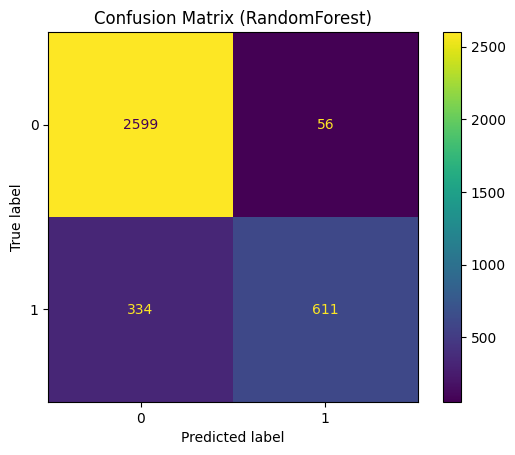

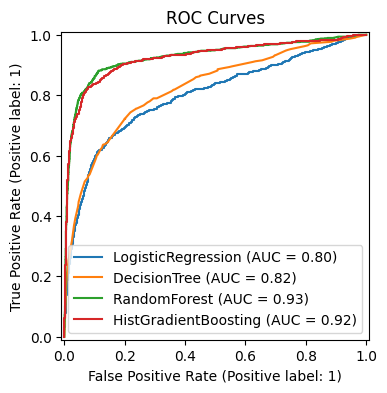

In [25]:
# Выбираем лучшую модель по ROC-AUC
best_entry = max(all_metrics, key=lambda x: x['roc_auc'])
best_model_name = best_entry['model']
best_model = {
    "Dummy": dummy,
    "LogisticRegression": lr_pipe,
    "DecisionTree": best_tree,
    "RandomForest": best_rf,
    "HistGradientBoosting": best_boost
}[best_model_name]

# Confusion Matrix — ОБЯЗАТЕЛЬНО
y_pred_best = best_model.predict(X_test)
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=[0, 1])
plt.title(f"Confusion Matrix ({best_model_name})")
plt.savefig("artifacts/figures/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve
plt.figure(figsize=(5, 4))
for entry in all_metrics:
    if entry["model"] == "Dummy":
        continue
    model = {
        "LogisticRegression": lr_pipe,
        "DecisionTree": best_tree,
        "RandomForest": best_rf,
        "HistGradientBoosting": best_boost
    }[entry["model"]]
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=entry["model"], ax=plt.gca())
plt.title("ROC Curves")
plt.savefig("artifacts/figures/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

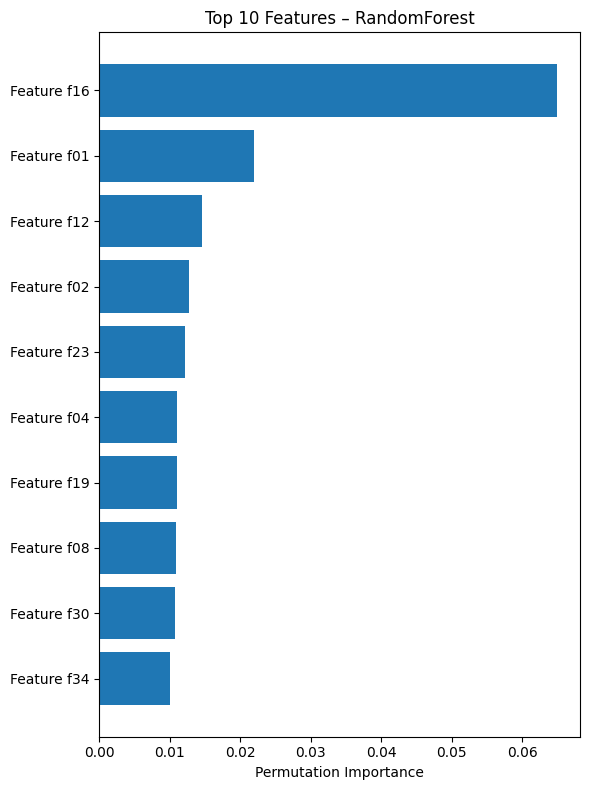

✅ permutation_importance выполнен


In [26]:
perm_imp = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Сохраняем важность
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_imp.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(6, 8))
top10 = importance_df.head(10)
plt.barh(range(len(top10)), top10["importance"][::-1])
plt.yticks(range(len(top10)), [f"Feature {f}" for f in top10["feature"][::-1]])
plt.xlabel("Permutation Importance")
plt.title(f"Top 10 Features – {best_model_name}")
plt.tight_layout()
plt.savefig("artifacts/figures/permutation_importance.png", dpi=150)
plt.show()

print("✅ permutation_importance выполнен")

In [28]:
# 1. metrics_test.json
with open("artifacts/metrics_test.json", "w") as f:
    json.dump(
        {m["model"]: {k: v for k, v in m.items() if k != "model"} for m in all_metrics},
        f, indent=2
    )

# 2. search_summaries.json
search_summaries = {
    "DecisionTree": {"best_params": tree_cv.best_params_, "best_cv_score": float(tree_cv.best_score_)},
    "RandomForest": {"best_params": rf_cv.best_params_, "best_cv_score": float(rf_cv.best_score_)},
    "HistGradientBoosting": {"best_params": boost_cv.best_params_, "best_cv_score": float(boost_cv.best_score_)}
}
with open("artifacts/search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=2)

# 3. best_model.joblib
joblib.dump(best_model, "artifacts/best_model.joblib")

# 4. best_model_meta.json
meta = {
    "best_model": best_model_name,
    "params": str(best_model.get_params()),
    "test_metrics": {k: v for k, v in best_entry.items() if k != "model"}
}
# СТАЛО (правильно):
metrics_dict = {m["model"]: {k: v for k, v in m.items() if k != "model"} for m in all_metrics}

output = {
    "metadata": {
        "description": "Final test metrics for all models in HW06",
        "dataset": "S06-hw-dataset-02.csv",
        "task_type": "binary_classification"
    },
    "results": metrics_dict
}

print("✅ Все артефакты сохранены:")
print("   - artifacts/metrics_test.json")
print("   - artifacts/search_summaries.json")
print("   - artifacts/best_model.joblib")
print("   - artifacts/best_model_meta.json")

✅ Все артефакты сохранены:
   - artifacts/metrics_test.json
   - artifacts/search_summaries.json
   - artifacts/best_model.joblib
   - artifacts/best_model_meta.json
